<a href="https://colab.research.google.com/github/Schimidel/UGRH-s-PrecipitacaoeTemperatura/blob/main/Proje%C3%A7%C3%B5es_Futuras_Precipita%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Informações da UGRH Paraná


In [1]:
%%capture
# Instalação de dependências no Google Colab
!pip install -U xarray[complete]
!pip install cartopy statsmodels geopandas shapely scipy


In [2]:
# Importação das bibliotecas necessárias
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from shapely.geometry import Polygon
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, LAND, COASTLINE
from scipy import stats
from scipy.stats import linregress


In [3]:
# Gerenciamento de caminhos (Colab / Local)
output_dir = './Dados'
if not os.path.exists(output_dir):
    output_dir = 'drive/MyDrive/Precipitacao_e_Indices'
    print(f'Rodando no Colab. Usando diretório: {output_dir}')
else:
    print(f'Rodando Localmente. Usando diretório: {output_dir}')

def load_dataset(filename):
    path = os.path.join(output_dir, filename)
    if os.path.exists(path):
        return xr.open_dataset(path)
    else:
        raise FileNotFoundError(f'Arquivo não encontrado: {path}')


Rodando Localmente. Usando diretório: ./Dados


In [ ]:
# Funções Auxiliares de Cálculo
def change_coords(ds):
    # Converte o grid de 0x360 longitude para -180x180
    ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
    ds = ds.sortby(ds.longitude)
    return ds

def calcula_media_movel(da, window=3):
    return da.rolling(year=window, center=True).mean()

def calcula_regressao(da):
    year = da.year
    val = da.pr
    slope, intercept, _, _, _ = linregress(year, val)
    regressao = slope * year + intercept
    return regressao, slope

def max_temp_year(ds):
    # Retorna o valor máximo anual
    return ds.groupby('time.year').max(dim='time')

def min_temp_year(ds):
    # Retorna o valor mínimo anual
    return ds.groupby('time.year').min(dim='time')

def calc_mean(ds, start_year, end_year):
    # Calcula a média espacial e temporal de um período
    ds = ds['pr']
    ds_mean = ds.mean(dim=['latitude', 'longitude'])
    temp_period = ds_mean.sel(time=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
    return temp_period.mean().item()

def calc_var(ds, start_year, end_year):
    # Calcula a variância espacial e temporal de um período
    temp_period = ds.sel(time=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
    return temp_period.var().item()

def remove_linear_trend(ds, start_year, end_year, time_name='time'):
    # Remove a tendência linear espacialmente média de um período
    ds_mean = ds.mean(dim=['latitude', 'longitude'])
    temperature = ds_mean.sel(time=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
    time = temperature['time']
    time_numeric = time.astype('datetime64[s]').astype(np.float64)
    slope, intercept, _, _, _ = stats.linregress(time_numeric, temperature.pr)
    trend = slope * time_numeric + intercept
    detrended = temperature - trend + trend[0]
    detrended['time'] = temperature['time']
    return detrended


In [5]:
# Carregamento dos Datasets de Precipitação
CCSM4 = load_dataset('CCSM4_pr.nc')
ACCESS1_3 = load_dataset('ACCESS1-3_pr.nc')
HadGEM2_ES = load_dataset('HadGEM2-ES_pr.nc')

CCSM4_rcp45 = load_dataset('RCP45-CCSM4_pr.nc')
ACCESS1_3_rcp45 = load_dataset('RCP45-ACCESS1-3_pr.nc')
HadGEM2_ES_rcp45 = load_dataset('RCP45-HadGEM2-ES_pr.nc')

CCSM4_rcp85 = load_dataset('RCP85-CCSM4_pr.nc')
ACCESS1_3_rcp85 = load_dataset('RCP85-ACCESS1-3_pr.nc')
HadGEM2_ES_rcp85 = load_dataset('RCP85-HadGEM2-ES_pr.nc')


In [6]:
# Cálculo da soma anual para cada ano
CCSM4_yrmean = CCSM4.groupby('time.year').sum('time')
ACCESS1_3_yrmean = ACCESS1_3.groupby('time.year').sum('time')
HadGEM2_ES_yrmean = HadGEM2_ES.groupby('time.year').sum('time')

CCSM4_rcp45_yrmean = CCSM4_rcp45.groupby('time.year').sum('time')
ACCESS1_3_rcp45_yrmean = ACCESS1_3_rcp45.groupby('time.year').sum('time')
HadGEM2_ES_rcp45_yrmean = HadGEM2_ES_rcp45.groupby('time.year').sum('time')

CCSM4_rcp85_yrmean = CCSM4_rcp85.groupby('time.year').sum('time')
ACCESS1_3_rcp85_yrmean = ACCESS1_3_rcp85.groupby('time.year').sum('time')
HadGEM2_ES_rcp85_yrmean = HadGEM2_ES_rcp85.groupby('time.year').sum('time')


In [7]:
# Cálculo das médias climatológicas de referência (30 anos: 1975 a 2004)
mean_CCSM4 = CCSM4_yrmean.sel(year=slice('1975', '2004')).mean(dim='year')
mean_ACCESS1_3 = ACCESS1_3_yrmean.sel(year=slice('1975', '2004')).mean(dim='year')
mean_HadGEM2_ES = HadGEM2_ES_yrmean.sel(year=slice('1975', '2004')).mean(dim='year')


In [8]:
# Cálculo das anomalias anuais
anom_CCSM4 = CCSM4_yrmean - mean_CCSM4
anom_ACCESS1_3 = ACCESS1_3_yrmean - mean_ACCESS1_3
anom_HadGEM2_ES = HadGEM2_ES_yrmean - mean_HadGEM2_ES

anom_CCSM4_rcp45 = CCSM4_rcp45_yrmean - mean_CCSM4
anom_ACCESS1_3_rcp45 = ACCESS1_3_rcp45_yrmean - mean_ACCESS1_3
anom_HadGEM2_ES_rcp45 = HadGEM2_ES_rcp45_yrmean - mean_HadGEM2_ES

anom_CCSM4_rcp85 = CCSM4_rcp85_yrmean - mean_CCSM4
anom_ACCESS1_3_rcp85 = ACCESS1_3_rcp85_yrmean - mean_ACCESS1_3
anom_HadGEM2_ES_rcp85 = HadGEM2_ES_rcp85_yrmean - mean_HadGEM2_ES


In [9]:
# Seleção dos recortes temporais adequados
anom_CCSM4 = anom_CCSM4.sel(year=slice('1851', '2004'))
anom_ACCESS1_3 = anom_ACCESS1_3.sel(year=slice('1851', '2004'))
anom_HadGEM2_ES = anom_HadGEM2_ES.sel(year=slice('1851', '2004'))

anom_CCSM4_rcp45 = anom_CCSM4_rcp45.sel(year=slice('2007', '2100'))
anom_ACCESS1_3_rcp45 = anom_ACCESS1_3_rcp45.sel(year=slice('2007', '2100'))
anom_HadGEM2_ES_rcp45 = anom_HadGEM2_ES_rcp45.sel(year=slice('2007', '2100'))

anom_CCSM4_rcp85 = anom_CCSM4_rcp85.sel(year=slice('2007', '2100'))
anom_ACCESS1_3_rcp85 = anom_ACCESS1_3_rcp85.sel(year=slice('2007', '2100'))
anom_HadGEM2_ES_rcp85 = anom_HadGEM2_ES_rcp85.sel(year=slice('2007', '2100'))


In [10]:
# Médias espaciais das anomalias
pr_CCSM4 = anom_CCSM4.mean(dim=['latitude', 'longitude'])
pr_ACCESS1_3 = anom_ACCESS1_3.mean(dim=['latitude', 'longitude'])
pr_HadGEM2_ES = anom_HadGEM2_ES.mean(dim=['latitude', 'longitude'])

pr_CCSM4_rcp45 = anom_CCSM4_rcp45.mean(dim=['latitude', 'longitude'])
pr_ACCESS1_3_rcp45 = anom_ACCESS1_3_rcp45.mean(dim=['latitude', 'longitude'])
pr_HadGEM2_ES_rcp45 = anom_HadGEM2_ES_rcp45.mean(dim=['latitude', 'longitude'])

pr_CCSM4_rcp85 = anom_CCSM4_rcp85.mean(dim=['latitude', 'longitude'])
pr_ACCESS1_3_rcp85 = anom_ACCESS1_3_rcp85.mean(dim=['latitude', 'longitude'])
pr_HadGEM2_ES_rcp85 = anom_HadGEM2_ES_rcp85.mean(dim=['latitude', 'longitude'])

# Desvios Padrão
std_CCSM4 = anom_CCSM4.std(dim=['latitude', 'longitude'])
std_ACCESS1_3 = anom_ACCESS1_3.std(dim=['latitude', 'longitude'])
std_HadGEM2_ES = anom_HadGEM2_ES.std(dim=['latitude', 'longitude'])

std_CCSM4_rcp45 = anom_CCSM4_rcp45.std(dim=['latitude', 'longitude'])
std_ACCESS1_3_rcp45 = anom_ACCESS1_3_rcp45.std(dim=['latitude', 'longitude'])
std_HadGEM2_ES_rcp45 = anom_HadGEM2_ES_rcp45.std(dim=['latitude', 'longitude'])

std_CCSM4_rcp85 = anom_CCSM4_rcp85.std(dim=['latitude', 'longitude'])
std_ACCESS1_3_rcp85 = anom_ACCESS1_3_rcp85.std(dim=['latitude', 'longitude'])
std_HadGEM2_ES_rcp85 = anom_HadGEM2_ES_rcp85.std(dim=['latitude', 'longitude'])


C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\3872128774.py:11: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  da_45 = xr.merge([hist, rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\3872128774.py:11: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  da_45 = xr.merge([hist, rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\387212

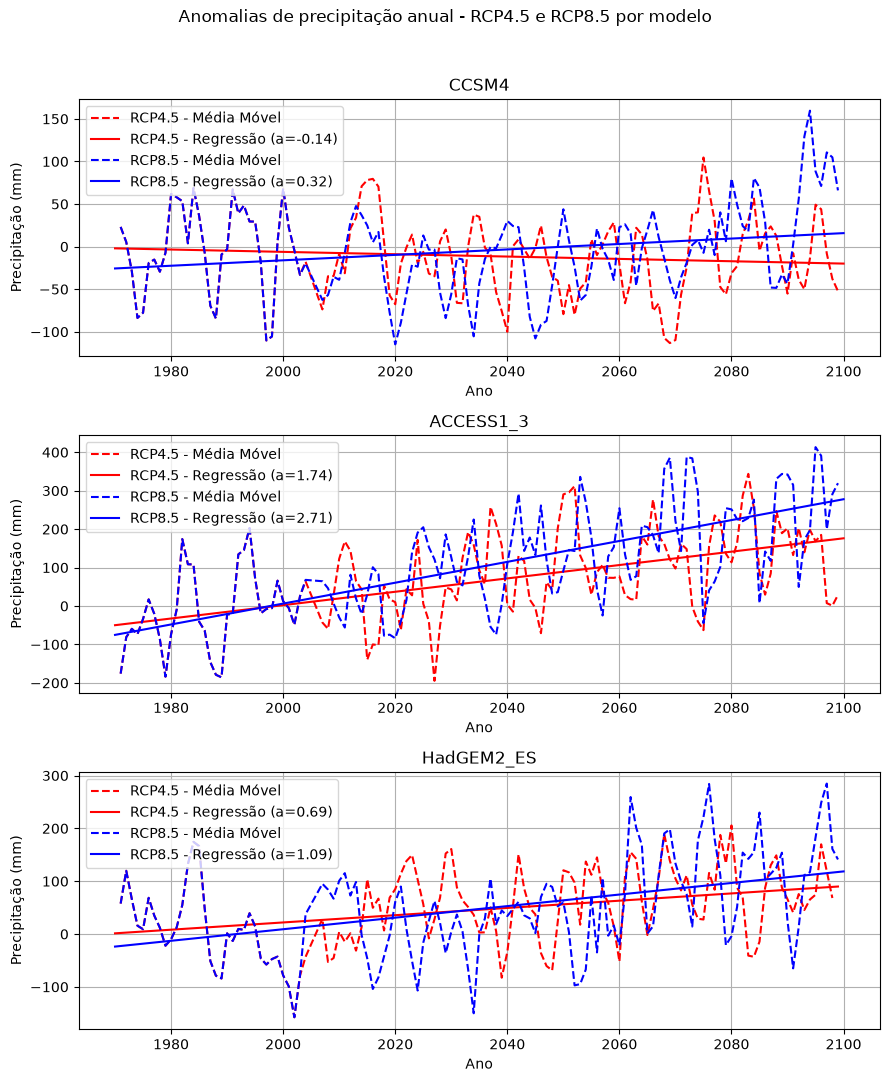

In [11]:
# Plotagem de tendências de Anomalias médias espaciais
modelos = {
    'CCSM4': (pr_CCSM4, pr_CCSM4_rcp45, pr_CCSM4_rcp85),
    'ACCESS1_3': (pr_ACCESS1_3, pr_ACCESS1_3_rcp45, pr_ACCESS1_3_rcp85),
    'HadGEM2_ES': (pr_HadGEM2_ES, pr_HadGEM2_ES_rcp45, pr_HadGEM2_ES_rcp85)
}
cores = {'rcp45': 'red', 'rcp85': 'blue'}

fig, axes = plt.subplots(3, 1, figsize=(9, 11))
for ax, (modelo, (hist, rcp45, rcp85)) in zip(axes, modelos.items()):
    da_45 = xr.merge([hist, rcp45])
    da_85 = xr.merge([hist, rcp85])

    mm_45 = calcula_media_movel(da_45)
    mm_85 = calcula_media_movel(da_85)
    reg_45, slope_45 = calcula_regressao(da_45)
    reg_85, slope_85 = calcula_regressao(da_85)

    ax.plot(mm_45.year, mm_45.pr, linestyle='--', color=cores['rcp45'], label='RCP4.5 - Média Móvel')
    ax.plot(da_45.year, reg_45, linestyle='-', color=cores['rcp45'], label=f'RCP4.5 - Regressão (a={slope_45:.2f})')
    ax.plot(mm_85.year, mm_85.pr, linestyle='--', color=cores['rcp85'], label='RCP8.5 - Média Móvel')
    ax.plot(da_85.year, reg_85, linestyle='-', color=cores['rcp85'], label=f'RCP8.5 - Regressão (a={slope_85:.2f})')

    ax.set_title(f'{modelo}')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Precipitação (mm)')
    ax.grid(True)
    ax.legend(loc='upper left')

plt.suptitle('Anomalias de precipitação anual - RCP4.5 e RCP8.5 por modelo', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [12]:
# Salvar anomalias calculadas em arquivos NetCDF
folder_path = './Dados_Anomalias_Futuros'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

for modelo, (hist, rcp45, rcp85) in modelos.items():
    da_45 = xr.merge([hist, rcp45])
    da_85 = xr.merge([hist, rcp85])
    file_45 = os.path.join(folder_path, f'{modelo}_anom_precip_rcp45.nc')
    file_85 = os.path.join(folder_path, f'{modelo}_anom_precip_rcp85.nc')
    da_45.to_netcdf(file_45)
    da_85.to_netcdf(file_85)
    print(f'Salvo: {file_45} e {file_85}')


C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\1699563641.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  da_45 = xr.merge([hist, rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\1699563641.py:7: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  da_45 = xr.merge([hist, rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\16995636

Salvo: ./Dados_Anomalias_Futuros\CCSM4_anom_precip_rcp45.nc e ./Dados_Anomalias_Futuros\CCSM4_anom_precip_rcp85.nc
Salvo: ./Dados_Anomalias_Futuros\ACCESS1_3_anom_precip_rcp45.nc e ./Dados_Anomalias_Futuros\ACCESS1_3_anom_precip_rcp85.nc
Salvo: ./Dados_Anomalias_Futuros\HadGEM2_ES_anom_precip_rcp45.nc e ./Dados_Anomalias_Futuros\HadGEM2_ES_anom_precip_rcp85.nc


C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\1699563641.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  da_45 = xr.merge([hist, rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\1699563641.py:7: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  da_45 = xr.merge([hist, rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_44196\16995636